In [1]:
import pandas as pd

In [2]:
#Cleaning Data - missing values

df = pd.read_csv("raw_data.csv")

df.isnull()

df.isnull().sum()

df.dropna()  #row drop
df.dropna(axis = 1)  #column drop

df.fillna(0)

cleaned_data = df.copy()
cleaned_data["age"] = cleaned_data["age"].fillna(df["age"].mean())


df.ffill()  #forward fill

df.bfill()  #backward fill

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,34.0,Canada,Female,62000.0
3,3,Alex,34.0,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,51000.0
5,5,Li Wei,27.0,China,Male,51000.0
6,6,Ahmed Khan,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,USA,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,31.0,Mexico,Male,45000.0


In [3]:
#Handle Duplicates

df.duplicated()
df2 = df.copy()
df.drop_duplicates(inplace=True)

In [12]:
#Data types

df.dtypes
df2 = df.copy()
df2 = df2.fillna(0)
df2["age"] = df2["age"].astype("int64").copy() 

df2.dtypes

id           int64
name        object
age          int64
country     object
gender      object
income     float64
dtype: object

In [13]:
date_str = pd.Series([pd.to_datetime("2026-12-31")])

type(date_str.dtypes)

numpy.dtypes.DateTime64DType

In [17]:
df["gender"].str.lower()
df["gender"].str.capitalize()

df["name"].str.split(" ")

df["country"].str.contains("india" , case = False)

0     False
1     False
2     False
3     False
4     False
5     False
6      True
7       NaN
8     False
9     False
10    False
Name: country, dtype: object

In [4]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [25]:
#Feature Engineering

df2 = df.copy()

df2["tax"] = df2["income"].apply(lambda x : "20%" if x>=50000 else "10%")


gender_map = {"Male" : "M" , "Female" : "F" , "Unknown" : "U"}

df2["gender"] = df2["gender"].map(gender_map)

df2 = df2.assign(new_income = df2["income"] * 1.1)

df2["country"] = df2["country"].replace("USA" , "United States")

df2.columns = ["ID" , "Name" , "Age","Country","Gender","Income","Tax","new_Income"]

df2.rename(columns={"Income":"Salary"})


df2.rename(index={1:"First"})

# df2.sort_values(["Income","Age"])
sorted_df = df2.sort_values(["Income","Age"] , ascending=False)

sorted_df.sort_index()

#reset

sorted_df.reset_index()

sorted_df.reset_index(drop = True)  #Used when we don't want to preserve original index order

#Ranking

sorted_df["Ranking"] = sorted_df["Income"].rank()
# sorted_df["Ranking"] = sorted_df["Income"].rank(ascending=False,method="dense")  #To resolve ties We can use min and max instead of dense

sorted_df

,ID,Name,Age,Country,Gender,Income,Tax,new_Income,Ranking
6,6,NaN,45.0,India,F,73000.0,20%,80300.0,10.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,74800.0,9.0
8,8,Rachel Lee,29.0,United States,F,62000.0,20%,68200.0,7.5
2,2,Jane Smith,NaN,Canada,F,62000.0,20%,68200.0,7.5
10,10,Emily Davis,31.0,United States,NaN,58000.0,20%,63800.0,6.0
0,1,John Doe,29.0,United States,M,55000.0,20%,60500.0,4.5
1,1,John Doe,29.0,United States,M,55000.0,20%,60500.0,4.5
5,5,Li Wei,27.0,China,M,51000.0,20%,56100.0,3.0
3,3,Alex,NaN,United States,U,47000.0,10%,51700.0,2.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,49500.0,1.0


In [15]:
df2

,id,name,age,country,gender,income,tax
0,1,John Doe,29.0,United States,M,55000.0,20%
1,1,John Doe,29.0,United States,M,55000.0,20%
2,2,Jane Smith,NaN,Canada,F,62000.0,20%
3,3,Alex,NaN,United States,U,47000.0,10%
4,4,Maria Garcia,34.0,Spain,F,NaN,10%
5,5,Li Wei,27.0,China,M,51000.0,20%
6,6,NaN,45.0,India,F,73000.0,20%
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%
8,8,Rachel Lee,29.0,United States,F,62000.0,20%
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%


In [26]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [27]:
df2 = df.copy()

new_col_order = [col for col in df2.columns if col != "id"] + ["id"]

df2[new_col_order]


,name,age,country,gender,income,id
0,John Doe,29.0,USA,Male,55000.0,1
1,John Doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Unknown,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Ruiz,NaN,Mexico,Male,45000.0,9


In [28]:
df2 = df.copy()

df2 = df2.drop_duplicates()

df2 = df2.fillna(0)
df2 = df2.sort_values("income")

df2.reset_index(drop = True)

df2.to_csv("sorted_data.csv")


,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0
10,10,Emily Davis,31.0,USA,NaN,58000.0


In [4]:
df.groupby("country")["income"].mean()
df.groupby("country")["income"].min()
df.groupby("country")["income"].max()

df.groupby("gender")["income"].mean()

df.groupby("country")["income"].agg(avg_salary = "mean" ,min_salary =  "min" ,max_salary = "max")

df.groupby("country").agg({
    "income" : "mean",
    "age" : "mean"
})


df.groupby("country").agg(
    max_salary=("income" , "max"),
    avg_age=("age" , "mean")
)

,max_salary,avg_age
country,,
Canada,62000.0,NaN
China,51000.0,27.000000
India,73000.0,45.000000
Mexico,45000.0,NaN
Spain,NaN,34.000000
USA,62000.0,29.666667


In [13]:
#Melt and Pivot

df = pd.DataFrame({
    "country" : ["USA","USA","India","India"],
    "year":[2020,2021,2020,2021],
    "sales":[100,120,90,110],
    "profit":[20,25,18,22],
    
})

melted_df = df.melt(
    id_vars = ["country","year"],
    value_vars=["sales","profit"],
    var_name = "metrics",
    value_name="value"
)

original = melted_df.pivot(
    index = ["country","year"],
    columns="metrics",
    values="value"
)
    

<Axes: xlabel='Age', ylabel='Salary'>

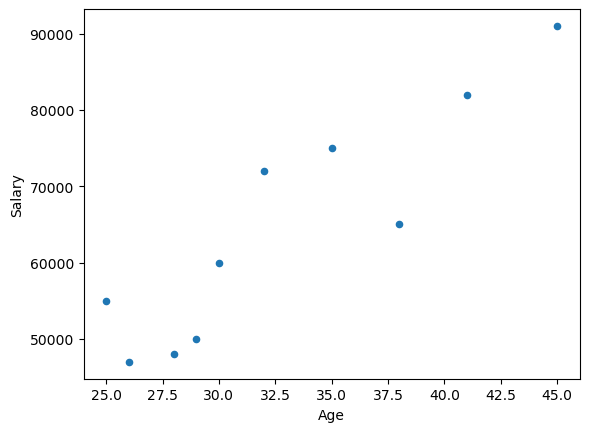

In [19]:
#Data Visualisation

df = pd.read_csv("employee_data.csv")

# df["Age"].hist()

df.plot(kind="scatter",x="Age",y="Salary")

In [16]:
df

,ID,Name,Age,Department,Salary
0,1,Alice,25,HR,55000
1,2,Bob,32,IT,72000
2,3,Charlie,28,Finance,48000
3,4,David,45,Marketing,91000
4,5,Eva,38,IT,65000
5,6,Frank,29,Finance,50000
6,7,Grace,41,HR,82000
7,8,Hannah,26,Marketing,47000
8,9,Ian,35,IT,75000
9,10,Julia,30,Finance,60000


In [20]:
# Merging and Joining data

df_customers = pd.DataFrame({
    "customer_id" : [1,2,3,4],
    "name":["Adam","Bob","Charlie","Dave"]
})

df_orders = pd.DataFrame({
    "order_id":[101,102,103,104],
    "customer_id":[2,1,4,5],
    "amount":[250,120,300,180]
})

pd.merge(df_customers,df_orders,on="customer_id")  #inner join
pd.merge(df_customers,df_orders,on="customer_id",how="left")  #left join
pd.merge(df_customers,df_orders,on="customer_id",how="right")  #Right join
pd.merge(df_customers,df_orders,on="customer_id",how="outer")  #outer join

In [21]:
df_customers

,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [22]:
df_orders

,order_id,customer_id,amount
0,101,2,250
1,102,1,120
2,103,4,300
3,104,5,180


In [24]:
# Concatenation

df1 = pd.DataFrame({
    "id" : [1,2,3],
    "name" : ["Adam","Eve","Bob"]
})

df2 = pd.DataFrame({
    "id" : [4,5,6],
    "name" : ["Charlie" ,"Fester","Gillian"]
})

pd.concat([df1,df2])  #row
pd.concat([df1,df2],ignore_index=True)  #row

pd.concat([df1,df2],axis=1) # col


,id,name,id,name
0,1,Adam,4,Charlie
1,2,Eve,5,Fester
2,3,Bob,6,Gillian
